# Challenge 1 — Búsqueda Inteligente y Optimización

## Sistema inteligente para determinar la ruta óptima de camiones mineros

- **Curso:** Machine Learning  
- **Unidad:** Fundamentos de IA y Búsqueda  
- **Plataforma:** Google Colab
- **Estudiante:** Juan Vidal Berrocal Ccapcha

## 1. Definición del problema

### Contexto

En una operación minera a cielo abierto, los camiones mineros
transportan material desde los frentes de carguío hasta las zonas de
descarga. Para realizar este transporte, los camiones deben desplazarse
por una red de caminos internos de la operación.

Los diferentes caminos presentan características distintas, como
distancia, pendiente, condición de la vía y nivel de congestión.
Estas características pueden afectar el tiempo de recorrido, el consumo
de combustible y el riesgo asociado al desplazamiento.

### Situación actual

Un camión minero se encuentra en el **frente de carguío (Carga)** y
debe transportar el material hasta la **zona de descarga (Descarga)**.

Entre ambos puntos existen diferentes caminos posibles. Por lo tanto,
el camión debe seleccionar una secuencia de tramos que le permita
llegar a su destino respetando las condiciones de operación.

### Problema

Se requiere determinar qué ruta debe seguir el camión minero desde
el frente de carguío hasta la zona de descarga, considerando las
características de los diferentes tramos de la red de transporte.

### Objetivo

Encontrar una ruta factible que permita al camión llegar a la zona
de descarga minimizando el costo operativo del recorrido.

Para ello se consideran tres factores principales:

- Tiempo de recorrido.
- Consumo de combustible.
- Riesgo del tramo.

### Pregunta guía

> **¿Qué ruta debe seguir el camión minero desde el frente de carguío
> hasta la zona de descarga para minimizar el costo operativo de su
> recorrido?**

### Formulación como problema de búsqueda

Para que el problema pueda ser tratado mediante una estrategia de
búsqueda, se transforma la situación real en los siguientes elementos:

| Elemento | Representación |
|---|---|
| Estado inicial | Carga |
| Estados | Carga, Cruce_A, Cruce_B, Cruce_C, Cruce_D, Cruce_E y Descarga |
| Acciones | Desplazarse hacia un nodo conectado |
| Transición | Movimiento desde un nodo hacia otro |
| Estado objetivo | Descarga |
| Restricciones | Tramos no permitidos y condiciones operativas |
| Función de costo | Tiempo + consumo de combustible + riesgo |


### Razonamiento aplicado

El problema puede analizarse mediante diferentes formas de
razonamiento:

- **Deductivo:** utiliza las restricciones conocidas para descartar
  rutas que no pueden ser utilizadas.

- **Inductivo:** utiliza información de recorridos y características
  observadas de los tramos para identificar patrones relacionados con
  el comportamiento del recorrido.

- **Abductivo:** permite plantear posibles explicaciones cuando el
  comportamiento observado de un recorrido no coincide con el
  comportamiento esperado.

## 2. Representación del problema

Para representar el problema de selección de rutas se modela la red de
transporte minero como un **grafo**, donde los puntos relevantes de la
red representan estados y las conexiones entre ellos representan los
tramos de desplazamiento disponibles.

Esta representación permite transformar la operación de transporte
minero en un problema de búsqueda sobre un espacio de estados.

Los elementos principales de la representación son:

- **Nodos:** representan el frente de carguío, cruces de caminos y zona
  de descarga.
- **Conexiones:** representan los tramos de carretera que permiten
  desplazarse entre dos estados.
- **Atributos del tramo:** representan características que influyen en
  el costo del desplazamiento, como distancia, pendiente y riesgo.
- **Ruta:** corresponde a una secuencia de nodos conectados desde el
  estado inicial hasta el estado objetivo.

In [1]:
import math
import matplotlib.pyplot as plt
from collections import deque

### 2.1 Definición de los estados

In [2]:
# Estados de la red minera
estados = [
    "Carga",
    "Cruce_A",
    "Cruce_B",
    "Cruce_C",
    "Cruce_D",
    "Cruce_E",
    "Descarga"
]

print("Estados del problema:")
for estado in estados:
    print("-", estado)

Estados del problema:
- Carga
- Cruce_A
- Cruce_B
- Cruce_C
- Cruce_D
- Cruce_E
- Descarga


### 2.2 Conexiones de la red

In [3]:
# Conexiones permitidas entre los estados
conexiones = {
    "Carga": ["Cruce_A", "Cruce_B"],
    "Cruce_A": ["Carga", "Cruce_C", "Cruce_D"],
    "Cruce_B": ["Carga", "Cruce_D"],
    "Cruce_C": ["Cruce_A", "Cruce_D", "Cruce_E", "Descarga"],
    "Cruce_D": ["Cruce_B", "Cruce_A", "Cruce_C", "Cruce_E", "Descarga"],
    "Cruce_E": ["Cruce_C", "Cruce_D", "Descarga"],
    "Descarga": ["Cruce_C", "Cruce_D", "Cruce_E"]
}
print("Conexiones de la red minera:\n")
for estado, vecinos in conexiones.items():
    print(estado, "→", vecinos)

Conexiones de la red minera:

Carga → ['Cruce_A', 'Cruce_B']
Cruce_A → ['Carga', 'Cruce_C', 'Cruce_D']
Cruce_B → ['Carga', 'Cruce_D']
Cruce_C → ['Cruce_A', 'Cruce_D', 'Cruce_E', 'Descarga']
Cruce_D → ['Cruce_B', 'Cruce_A', 'Cruce_C', 'Cruce_E', 'Descarga']
Cruce_E → ['Cruce_C', 'Cruce_D', 'Descarga']
Descarga → ['Cruce_C', 'Cruce_D', 'Cruce_E']


### 2.3 Características de los tramos
- **Distancia:** longitud del tramo recorrido.
- **Pendiente:** inclinación del tramo de carretera.
- **Riesgo:** indicador asociado a las condiciones del tramo.

In [4]:
# Características de cada tramo
tramos = {
    ("Carga", "Cruce_A"): {
        "distancia": 2.24,
        "pendiente": 5,
        "riesgo": 0.20
    },
    ("Carga", "Cruce_B"): {
        "distancia": 2.83,
        "pendiente": 3,
        "riesgo": 0.15
    },
    ("Cruce_A", "Cruce_C"): {
        "distancia": 3.16,
        "pendiente": 7,
        "riesgo": 0.25
    },
    ("Cruce_B", "Cruce_D"): {
        "distancia": 3.16,
        "pendiente": 4,
        "riesgo": 0.10
    },
    ("Cruce_A", "Cruce_D"): {
        "distancia": 3.61,
        "pendiente": 10,
        "riesgo": 0.35
    },
    ("Cruce_C", "Cruce_E"): {
        "distancia": 2.24,
        "pendiente": 6,
        "riesgo": 0.18
    },
    ("Cruce_D", "Cruce_E"): {
        "distancia": 2.83,
        "pendiente": 5,
        "riesgo": 0.12
    },
    ("Cruce_C", "Cruce_D"): {
        "distancia": 3.00,
        "pendiente": 8,
        "riesgo": 0.22
    },
    ("Cruce_C", "Descarga"): {
        "distancia": 4.12,
        "pendiente": 4,
        "riesgo": 0.08
    },
    ("Cruce_D", "Descarga"): {
        "distancia": 4.47,
        "pendiente": 6,
        "riesgo": 0.15
    },

    ("Cruce_E", "Descarga"): {
        "distancia": 2.00,
        "pendiente": 3,
        "riesgo": 0.05
    }
}
print("Cantidad de tramos:", len(tramos))

Cantidad de tramos: 11


In [5]:
#Verificamos nuestros datos
print("TRAMOS DE LA RED MINERA\n")
for (origen, destino), datos in tramos.items():
    print(
        f"{origen} → {destino} | "
        f"Distancia: {datos['distancia']} km | "
        f"Pendiente: {datos['pendiente']}% | "
        f"Riesgo: {datos['riesgo']}"
    )

TRAMOS DE LA RED MINERA

Carga → Cruce_A | Distancia: 2.24 km | Pendiente: 5% | Riesgo: 0.2
Carga → Cruce_B | Distancia: 2.83 km | Pendiente: 3% | Riesgo: 0.15
Cruce_A → Cruce_C | Distancia: 3.16 km | Pendiente: 7% | Riesgo: 0.25
Cruce_B → Cruce_D | Distancia: 3.16 km | Pendiente: 4% | Riesgo: 0.1
Cruce_A → Cruce_D | Distancia: 3.61 km | Pendiente: 10% | Riesgo: 0.35
Cruce_C → Cruce_E | Distancia: 2.24 km | Pendiente: 6% | Riesgo: 0.18
Cruce_D → Cruce_E | Distancia: 2.83 km | Pendiente: 5% | Riesgo: 0.12
Cruce_C → Cruce_D | Distancia: 3.0 km | Pendiente: 8% | Riesgo: 0.22
Cruce_C → Descarga | Distancia: 4.12 km | Pendiente: 4% | Riesgo: 0.08
Cruce_D → Descarga | Distancia: 4.47 km | Pendiente: 6% | Riesgo: 0.15
Cruce_E → Descarga | Distancia: 2.0 km | Pendiente: 3% | Riesgo: 0.05


### 2.4 Costo básico de cada tramo
Para poder comparar los diferentes tramos de la red se define inicialmente
una función de costo básica.

Esta función combina tres características disponibles en la representación
del problema: distancia, pendiente y riesgo.

$$Costo = Distancia + 0.5 \cdot Pendiente + 5 \cdot Riesgo$$

In [6]:
# Calcular el costo de cada tramo
for tramo, datos in tramos.items():
    distancia = datos["distancia"]
    pendiente = datos["pendiente"]
    riesgo = datos["riesgo"]
    costo = (
        distancia
        + 0.5 * pendiente
        + 5 * riesgo
    )
    datos["costo"] = round(costo, 2)

print("Costos calculados correctamente.")

Costos calculados correctamente.


### 2.5 Costos obtenidos

Una vez aplicada la función de costo, se muestran los valores calculados
para cada tramo de la red.

Esto permite comprobar que cada conexión posee un costo asociado que
podrá ser utilizado por los algoritmos de búsqueda.

In [7]:
#mostramos los costos
print("COSTO DE CADA TRAMO\n")
for (origen, destino), datos in tramos.items():
    print(
        f"{origen} → {destino} | "
        f"Costo = {datos['costo']}"
    )

COSTO DE CADA TRAMO

Carga → Cruce_A | Costo = 5.74
Carga → Cruce_B | Costo = 5.08
Cruce_A → Cruce_C | Costo = 7.91
Cruce_B → Cruce_D | Costo = 5.66
Cruce_A → Cruce_D | Costo = 10.36
Cruce_C → Cruce_E | Costo = 6.14
Cruce_D → Cruce_E | Costo = 5.93
Cruce_C → Cruce_D | Costo = 8.1
Cruce_C → Descarga | Costo = 6.52
Cruce_D → Descarga | Costo = 8.22
Cruce_E → Descarga | Costo = 3.75


### 2.6 Consulta del costo de un tramo

Se implementa una función que permite obtener el costo asociado a una
conexión entre dos estados.

Debido a que la red se ha modelado como bidireccional, la función
comprueba tanto la conexión directa como la conexión inversa.

Si el tramo no existe, la función retorna `None`.

In [8]:
#creamos una funcion para obtener el costo
def obtener_costo(origen, destino):
    if (origen, destino) in tramos:
        return tramos[(origen, destino)]["costo"]
    if (destino, origen) in tramos:
        return tramos[(destino, origen)]["costo"]
    return None

In [9]:
#probamos
print("Costo Carga → Cruce_A:",
      obtener_costo("Carga", "Cruce_A"))

print("Costo Cruce_A → Cruce_D:",
      obtener_costo("Cruce_A", "Cruce_D"))

Costo Carga → Cruce_A: 5.74
Costo Cruce_A → Cruce_D: 10.36


### 2.7 Estructura conceptual de la red
La representación puede resumirse mediante la siguiente relación:

**Red minera → Estados → Transiciones → Características de los tramos
→ Función de costo**

                RED MINERA
                    ↓
        ┌──────────────────────┐
        │       Estados        │
        │ Carga                │
        │ Cruces               │
        │ Descarga             │
        └──────────┬───────────┘
                   ↓
        ┌──────────────────────┐
        │     Transiciones     │
        │ A → B                │
        │ A → C                │
        │ etc.                 │
        └──────────┬───────────┘
                   ↓
        ┌──────────────────────┐
        │   Características    │
        │ Distancia            │
        │ Pendiente            │
        │ Riesgo               │
        └──────────┬───────────┘
                   ↓
        ┌──────────────────────┐
        │    FUNCIÓN COSTO     │
        │ Distancia            │
        │ + Pendiente          │
        │ + Riesgo             │
        └──────────────────────┘

### 2.8 Coordenadas para la visualización

Se asignan coordenadas bidimensionales a cada estado con el propósito de
visualizar gráficamente la estructura de la red.

Estas coordenadas se utilizan únicamente para organizar visualmente
los nodos de la red y no representan coordenadas geográficas reales
ni intervienen directamente en el cálculo del costo de los tramos.

In [10]:
# Coordenadas de los estados para visualizar la red
coordenadas = {
    "Carga": (0, 0),
    "Cruce_A": (2, 1),
    "Cruce_B": (2, -2),
    "Cruce_C": (5, 1),
    "Cruce_D": (5, -2),
    "Cruce_E": (7, 0),
    "Descarga": (9, 0)
}

print("Coordenadas creadas correctamente.")

Coordenadas creadas correctamente.


In [11]:
print("COORDENADAS DE LA RED\n")

for estado, posicion in coordenadas.items():
    print(estado, "→", posicion)

COORDENADAS DE LA RED

Carga → (0, 0)
Cruce_A → (2, 1)
Cruce_B → (2, -2)
Cruce_C → (5, 1)
Cruce_D → (5, -2)
Cruce_E → (7, 0)
Descarga → (9, 0)


### 2.9 Representación gráfica de la red minera

La red minera se representa gráficamente mediante sus estados,
conexiones y costos asociados a cada tramo.

Los nodos representan los estados de la red, mientras que las
conexiones representan los desplazamientos posibles entre ellos.
El valor mostrado sobre cada conexión corresponde al costo básico
calculado previamente.

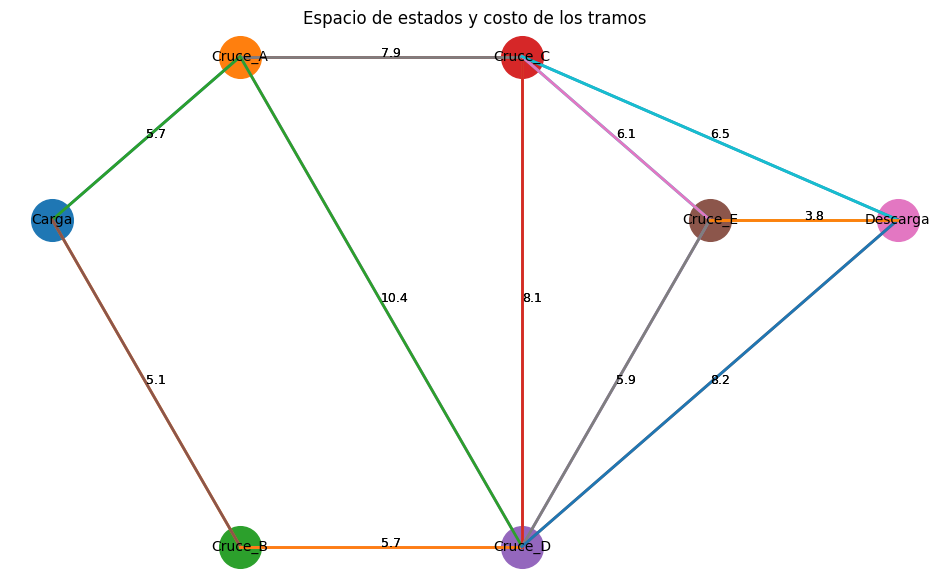

In [12]:
# Visualizar el espacio de estados
plt.figure(figsize=(12, 7))
# Dibujar los caminos
for origen, vecinos in conexiones.items():
    for destino in vecinos:
        x1, y1 = coordenadas[origen]
        x2, y2 = coordenadas[destino]
        plt.plot(
            [x1, x2],
            [y1, y2],
            linewidth=2
        )
# Dibujar los estados
for nombre, (x, y) in coordenadas.items():
    plt.scatter(x, y, s=900)
    plt.text(
        x,
        y,
        nombre,
        ha="center",
        va="center",
        fontsize=10
    )
# Mostrar costos
for origen, vecinos in conexiones.items():
    for destino in vecinos:
        costo = obtener_costo(origen, destino)
        x1, y1 = coordenadas[origen]
        x2, y2 = coordenadas[destino]
        xm = (x1 + x2) / 2
        ym = (y1 + y2) / 2
        if costo is not None:
            plt.text(
                xm,
                ym,
                f"{costo:.1f}",
                fontsize=9
            )
plt.title("Espacio de estados y costo de los tramos")
plt.axis("off")
plt.show()

### 2.10 Verificación de conectividad de la red
Antes de aplicar las estrategias de búsqueda orientadas a la
optimización, se verifica que exista una ruta entre el estado inicial
`Carga` y el estado objetivo `Descarga`.

La función implementada realiza una exploración recursiva de las
conexiones disponibles y devuelve una ruta factible cuando encuentra
una secuencia de estados que conecta ambos puntos.

Esta etapa tiene como propósito comprobar la conectividad de la red,
pero no determina todavía la ruta de menor costo.

In [13]:
# Función para obtener una ruta entre dos estados
def obtener_ruta(origen, destino, visitados=None):
    if visitados is None:
        visitados = []
    visitados = visitados + [origen]
    if origen == destino:
        return visitados
    for vecino in conexiones[origen]:
        if vecino not in visitados:
            ruta = obtener_ruta(
                vecino,
                destino,
                visitados
            )
            if ruta is not None:
                return ruta
    return None

In [14]:
ruta = obtener_ruta("Carga", "Descarga")
print("Ruta encontrada:")
print(" → ".join(ruta))

Ruta encontrada:
Carga → Cruce_A → Cruce_C → Cruce_D → Cruce_E → Descarga


## 3. Estrategias de búsqueda

Una vez representada la red minera como un espacio de estados, se
aplican estrategias de búsqueda para explorar las diferentes rutas
posibles entre el estado inicial `Carga` y el estado objetivo
`Descarga`.

Como primera etapa se utilizan estrategias de búsqueda no informadas:
**Búsqueda en Anchura (BFS)** y **Búsqueda en Profundidad (DFS)**.

Estas estrategias permiten analizar cómo se comporta la exploración del
espacio de estados antes de incorporar el costo de los tramos en la
selección de la ruta.

### 3.1 Búsqueda en Anchura (BFS)

In [15]:
# Búsqueda en Anchura (BFS)
def bfs(inicio, objetivo):
    cola = deque([[inicio]])
    visitados = []
    while cola:
        ruta = cola.popleft()
        estado = ruta[-1]
        if estado == objetivo:
            return ruta
        if estado not in visitados:
            visitados.append(estado)
            for vecino in conexiones[estado]:
                if vecino not in visitados:
                    nueva_ruta = ruta + [vecino]
                    cola.append(nueva_ruta)

    return None

In [16]:
ruta_bfs = bfs("Carga", "Descarga")
print("Ruta encontrada mediante BFS:")
print(" → ".join(ruta_bfs))
print("\nNúmero de estados recorridos:", len(ruta_bfs))

Ruta encontrada mediante BFS:
Carga → Cruce_A → Cruce_C → Descarga

Número de estados recorridos: 4


**Interpretación:**

BFS encuentra una ruta desde `Carga` hasta `Descarga` utilizando tres
transiciones y cuatro estados.

La ruta encontrada representa una solución factible dentro del espacio
de estados. Sin embargo, el algoritmo no determina si dicha ruta
presenta el menor costo operativo.

### 3.2 Búsqueda en Profundidad (DFS)


In [17]:
# Búsqueda en Profundidad (DFS)
def dfs(inicio, objetivo):
    pila = [[inicio]]
    visitados = []
    while pila:
        ruta = pila.pop()
        estado = ruta[-1]
        if estado == objetivo:
            return ruta
        if estado not in visitados:
            visitados.append(estado)
            for vecino in conexiones[estado]:
                if vecino not in visitados:
                    nueva_ruta = ruta + [vecino]
                    pila.append(nueva_ruta)

    return None

In [18]:
ruta_dfs = dfs("Carga", "Descarga")
print("Ruta encontrada mediante DFS:")
print(" → ".join(ruta_dfs))
print("\nNúmero de estados recorridos:", len(ruta_dfs))

Ruta encontrada mediante DFS:
Carga → Cruce_B → Cruce_D → Descarga

Número de estados recorridos: 4


**Interpretación:**

DFS encuentra una ruta factible entre el estado inicial y el estado
objetivo.

En este caso, la exploración selecciona primero la alternativa que
conduce desde `Carga` hacia `Cruce_B` y posteriormente hacia
`Cruce_D`, hasta alcanzar `Descarga`.

La ruta obtenida no debe interpretarse como la ruta de menor costo,
debido a que DFS no utiliza los costos asociados a los tramos durante
la exploración.

### Comparación BFS vs. DFS

In [19]:
# Comparación entre BFS y DFS
ruta_bfs = bfs("Carga", "Descarga")
ruta_dfs = dfs("Carga", "Descarga")
print("COMPARACIÓN BFS VS DFS\n")
print("BFS:")
print(" → ".join(ruta_bfs))
print("Estados de la ruta:", len(ruta_bfs))
print("\nDFS:")
print(" → ".join(ruta_dfs))
print("Estados de la ruta:", len(ruta_dfs))

COMPARACIÓN BFS VS DFS

BFS:
Carga → Cruce_A → Cruce_C → Descarga
Estados de la ruta: 4

DFS:
Carga → Cruce_B → Cruce_D → Descarga
Estados de la ruta: 4


### 3.3 Comparación BFS vs. DFS

En este escenario ambas estrategias encuentran una ruta entre `Carga` y
`Descarga` utilizando cuatro estados.

Sin embargo, las estrategias presentan diferentes mecanismos de
exploración:

**BFS**
- Explora el espacio de estados por niveles.
- Permite encontrar una ruta con el menor número de transiciones cuando
  los costos de las transiciones son uniformes.
- No utiliza los costos específicos de los tramos en esta implementación.

**DFS**
- Explora una alternativa en profundidad antes de retroceder.
- Puede encontrar una solución sin explorar inicialmente todo el espacio
  de estados.
- La ruta encontrada depende del orden de las conexiones.
- No utiliza los costos específicos de los tramos en esta implementación.

### 3.4 Búsqueda por Fuerza Bruta

Para establecer una referencia sobre la solución del problema, se
implementa una búsqueda por fuerza bruta.

Esta estrategia genera las rutas factibles entre el estado inicial
`Carga` y el estado objetivo `Descarga`, evitando repetir estados dentro
de una misma ruta.

Una vez generadas las rutas, se calcula el costo acumulado de cada una
y se selecciona aquella que presenta el menor costo dentro del conjunto
explorado.

La fuerza bruta se utiliza como referencia de comparación para evaluar
posteriormente el comportamiento de una estrategia de búsqueda
informada.

In [20]:
# Búsqueda de Fuerza Bruta (BF)
def generar_rutas(actual, objetivo, ruta=None):
    if ruta is None:
        ruta = []
    ruta = ruta + [actual]
    if actual == objetivo:
        return [ruta]
    rutas = []
    for vecino in conexiones[actual]:
        if vecino not in ruta:
            nuevas_rutas = generar_rutas(
                vecino,
                objetivo,
                ruta
            )
            rutas.extend(nuevas_rutas)
    return rutas

In [21]:
rutas = generar_rutas("Carga", "Descarga")
print("RUTAS POSIBLES ENCONTRADAS:", len(rutas))
for i, ruta in enumerate(rutas, 1):
    print(f"Ruta {i}: " + " → ".join(ruta))

RUTAS POSIBLES ENCONTRADAS: 17
Ruta 1: Carga → Cruce_A → Cruce_C → Cruce_D → Cruce_E → Descarga
Ruta 2: Carga → Cruce_A → Cruce_C → Cruce_D → Descarga
Ruta 3: Carga → Cruce_A → Cruce_C → Cruce_E → Cruce_D → Descarga
Ruta 4: Carga → Cruce_A → Cruce_C → Cruce_E → Descarga
Ruta 5: Carga → Cruce_A → Cruce_C → Descarga
Ruta 6: Carga → Cruce_A → Cruce_D → Cruce_C → Cruce_E → Descarga
Ruta 7: Carga → Cruce_A → Cruce_D → Cruce_C → Descarga
Ruta 8: Carga → Cruce_A → Cruce_D → Cruce_E → Cruce_C → Descarga
Ruta 9: Carga → Cruce_A → Cruce_D → Cruce_E → Descarga
Ruta 10: Carga → Cruce_A → Cruce_D → Descarga
Ruta 11: Carga → Cruce_B → Cruce_D → Cruce_A → Cruce_C → Cruce_E → Descarga
Ruta 12: Carga → Cruce_B → Cruce_D → Cruce_A → Cruce_C → Descarga
Ruta 13: Carga → Cruce_B → Cruce_D → Cruce_C → Cruce_E → Descarga
Ruta 14: Carga → Cruce_B → Cruce_D → Cruce_C → Descarga
Ruta 15: Carga → Cruce_B → Cruce_D → Cruce_E → Cruce_C → Descarga
Ruta 16: Carga → Cruce_B → Cruce_D → Cruce_E → Descarga
Ruta 17: Car

En el escenario utilizado se obtienen **17 rutas posibles**. Estas rutas
serán evaluadas mediante la función de costo para determinar el menor
costo encontrado en la exploración.

### 3.5 Evaluación del costo de las rutas
Cada ruta generada se evalúa mediante la suma de los costos de sus tramos.

La función de costo total de una ruta se expresa como:

$$C(R)=\sum_{i=1}^{n-1} C(s_i,s_{i+1})$$

donde:

- $R$ representa una ruta.
- $s_i$ representa un estado de la ruta.
- $C(s_i,s_{i+1})$ representa el costo del tramo entre dos estados consecutivos.


De esta manera, las diferentes rutas pueden compararse utilizando una
misma función de costo.

In [22]:
# Calcular el costo total de una ruta
def calcular_costo_ruta(ruta):
    costo_total = 0
    for i in range(len(ruta) - 1):
        origen = ruta[i]
        destino = ruta[i + 1]
        costo = obtener_costo(origen, destino)
        costo_total += costo
    return round(costo_total, 2)

In [23]:
print("COSTO DE TODAS LAS RUTAS\n")
for i, ruta in enumerate(rutas, 1):
    costo = calcular_costo_ruta(ruta)
    print(
        f"Ruta {i}: "
        + " → ".join(ruta)
        + f" | Costo total = {costo}"
    )

COSTO DE TODAS LAS RUTAS

Ruta 1: Carga → Cruce_A → Cruce_C → Cruce_D → Cruce_E → Descarga | Costo total = 31.43
Ruta 2: Carga → Cruce_A → Cruce_C → Cruce_D → Descarga | Costo total = 29.97
Ruta 3: Carga → Cruce_A → Cruce_C → Cruce_E → Cruce_D → Descarga | Costo total = 33.94
Ruta 4: Carga → Cruce_A → Cruce_C → Cruce_E → Descarga | Costo total = 23.54
Ruta 5: Carga → Cruce_A → Cruce_C → Descarga | Costo total = 20.17
Ruta 6: Carga → Cruce_A → Cruce_D → Cruce_C → Cruce_E → Descarga | Costo total = 34.09
Ruta 7: Carga → Cruce_A → Cruce_D → Cruce_C → Descarga | Costo total = 30.72
Ruta 8: Carga → Cruce_A → Cruce_D → Cruce_E → Cruce_C → Descarga | Costo total = 34.69
Ruta 9: Carga → Cruce_A → Cruce_D → Cruce_E → Descarga | Costo total = 25.78
Ruta 10: Carga → Cruce_A → Cruce_D → Descarga | Costo total = 24.32
Ruta 11: Carga → Cruce_B → Cruce_D → Cruce_A → Cruce_C → Cruce_E → Descarga | Costo total = 38.9
Ruta 12: Carga → Cruce_B → Cruce_D → Cruce_A → Cruce_C → Descarga | Costo total = 35.5

### 3.6 Resultado de la búsqueda por Fuerza Bruta

Después de evaluar las rutas generadas, se identifica la ruta con menor
costo dentro del conjunto explorado.

In [24]:
# Seleccionar la ruta de menor costo mediante Fuerza Bruta
mejor_ruta = None
menor_costo = float("inf")
for ruta in rutas:
    costo = calcular_costo_ruta(ruta)
    if costo < menor_costo:
        menor_costo = costo
        mejor_ruta = ruta
print("RESULTADO DE FUERZA BRUTA\n")
print("Mejor ruta:")
print(" → ".join(mejor_ruta))
print("\nCosto total:", menor_costo)

RESULTADO DE FUERZA BRUTA

Mejor ruta:
Carga → Cruce_B → Cruce_D → Descarga

Costo total: 18.96


### 3.7 Búsqueda informada mediante A*

Después de analizar las estrategias de búsqueda no informadas y utilizar la fuerza bruta como referencia, se implementa A* como estrategia de búsqueda informada.

A* combina dos componentes para orientar la exploración:

$$f(n)=g(n)+h(n)$$

donde:

- $g(n)$: costo acumulado desde el estado inicial hasta el estado actual.
- $h(n)$: estimación del costo restante desde el estado actual hasta el objetivo.
- $f(n)$: valor utilizado para priorizar los estados durante la búsqueda.

Para este escenario, la heurística $h(n)$ se calcula mediante la distancia euclidiana entre las coordenadas asignadas a los estados.

In [25]:
# Búsqueda A*
def distancia_heuristica(origen, objetivo):
    x1, y1 = coordenadas[origen]
    x2, y2 = coordenadas[objetivo]

    return math.sqrt((x2 - x1) ** 2 +(y2 - y1) ** 2)
def a_estrella(inicio, objetivo):
    abiertos = [
        {
            "estado": inicio,
            "ruta": [inicio],
            "g": 0,
            "f": distancia_heuristica(inicio, objetivo)
        }
    ]
    visitados = []
    while abiertos:
        mejor = min(
            abiertos,
            key=lambda x: x["f"]
        )
        abiertos.remove(mejor)
        estado = mejor["estado"]
        ruta = mejor["ruta"]
        costo_actual = mejor["g"]
        if estado == objetivo:
            return ruta, costo_actual
        if estado in visitados:
            continue
        visitados.append(estado)
        for vecino in conexiones[estado]:
            if vecino in visitados:
                continue
            costo_tramo = obtener_costo(estado, vecino)
            nuevo_g = costo_actual + costo_tramo
            h = distancia_heuristica(vecino,objetivo)
            nuevo_f = nuevo_g + h
            nueva_ruta = ruta + [vecino]
            abiertos.append(
                {
                    "estado": vecino,
                    "ruta": nueva_ruta,
                    "g": nuevo_g,
                    "f": nuevo_f
                }
            )

    return None, None

### 3.8 Resultado de A*

La búsqueda A* obtiene la siguiente ruta para el escenario evaluado:

$$\text{Carga} \rightarrow \text{Cruce_B} \rightarrow \text{Cruce_D} \rightarrow \text{Descarga}$$

El costo acumulado de la ruta es:

$$C = 18.96$$

La solución obtenida será comparada con el resultado obtenido mediante fuerza bruta.

In [26]:
ruta_a_estrella, costo_a_estrella = a_estrella(
    "Carga",
    "Descarga"
)

print("RESULTADO DE A*\n")

print("Ruta encontrada:")
print(" → ".join(ruta_a_estrella))

print("\nCosto total:", round(costo_a_estrella, 2))

RESULTADO DE A*

Ruta encontrada:
Carga → Cruce_B → Cruce_D → Descarga

Costo total: 18.96


In [27]:
# Comparación entre Fuerza Bruta y A*
print("COMPARACIÓN FUERZA BRUTA VS A*\n")
print("FUERZA BRUTA")
print("Ruta:", " → ".join(mejor_ruta))
print("Costo:", menor_costo)
print("\nA*")
print("Ruta:", " → ".join(ruta_a_estrella))
print("Costo:", round(costo_a_estrella, 2))
print("\nCOMPARACIÓN")
if menor_costo == round(costo_a_estrella, 2):
    print("A* encontró una ruta con el mismo costo que Fuerza Bruta.")
else:
    print("A* encontró una ruta con un costo diferente.")

COMPARACIÓN FUERZA BRUTA VS A*

FUERZA BRUTA
Ruta: Carga → Cruce_B → Cruce_D → Descarga
Costo: 18.96

A*
Ruta: Carga → Cruce_B → Cruce_D → Descarga
Costo: 18.96

COMPARACIÓN
A* encontró una ruta con el mismo costo que Fuerza Bruta.


### 3.8.1 Análisis de los valores de A*

Para interpretar el comportamiento de A*, se muestran los valores utilizados para los estados pertenecientes a la ruta obtenida.

- $g(n)$: costo acumulado desde el estado inicial hasta el estado actual.
- $h(n)$: estimación de la distancia restante hasta el estado objetivo.
- $f(n)$: valor utilizado por A* para orientar la búsqueda.

La función utilizada es:

$$f(n)=g(n)+h(n)$$

En este caso, $h(n)$ se obtiene mediante la distancia euclidiana calculada a partir de las coordenadas utilizadas para representar gráficamente la red.

In [28]:
# Analizar los valores g(n), h(n) y f(n) de la ruta obtenida
def analizar_ruta_a_estrella(ruta, objetivo):
    g = 0
    print("ANÁLISIS DE LA RUTA OBTENIDA MEDIANTE A*\n")
    print(f"{'Estado':<12} {'g(n)':>8} {'h(n)':>8} {'f(n)':>8}")
    print("-" * 40)
    for i, estado in enumerate(ruta):
        # Calcular el costo acumulado g(n)
        if i > 0:
            origen = ruta[i - 1]
            g += obtener_costo(origen, estado)
        # Calcular la heurística h(n)
        h = distancia_heuristica(estado, objetivo)
        # Calcular f(n)
        f = g + h
        print(f"{estado:<12} {g:>8.2f} {h:>8.2f} {f:>8.2f}")
# Analizar la ruta encontrada
analizar_ruta_a_estrella(
    ruta_a_estrella,
    "Descarga"
)

ANÁLISIS DE LA RUTA OBTENIDA MEDIANTE A*

Estado           g(n)     h(n)     f(n)
----------------------------------------
Carga            0.00     9.00     9.00
Cruce_B          5.08     7.28    12.36
Cruce_D         10.74     4.47    15.21
Descarga        18.96     0.00    18.96


### Interpretación de la búsqueda

El análisis de la ruta muestra cómo interactúan el costo acumulado y la estimación restante:

- **Comportamiento:** A medida que la ruta avanza hacia `Descarga`, $g(n)$ se incrementa por los tramos recorridos, mientras que $h(n)$ se reduce hasta alcanzar $0$ en el objetivo.
- **Resultado:** Para la ruta $\text{Carga} \rightarrow \text{Cruce_B} \rightarrow \text{Cruce_D} \rightarrow \text{Descarga}$, el costo acumulado final es $g(\text{Descarga}) = 18.96$.

Este valor iguala el costo mínimo determinado por la búsqueda por Fuerza Bruta.

## 3.9 Comparación entre Fuerza Bruta y A*

La búsqueda por Fuerza Bruta explora las rutas factibles del espacio
definido y permite establecer una referencia del menor costo encontrado
para el escenario.

A* utiliza una estrategia informada mediante la combinación del costo
acumulado \(g(n)\) y una heurística \(h(n)\), orientando la exploración
hacia el estado objetivo.

### Resultados

| Estrategia | Ruta encontrada | Costo |
|---|---|---:|
| Fuerza Bruta | Carga → Cruce_B → Cruce_D → Descarga | 18.96 |
| A* | Carga → Cruce_B → Cruce_D → Descarga | 18.96 |

En el escenario evaluado, ambas estrategias obtienen la misma ruta y el
mismo costo acumulado.

La Fuerza Bruta se utiliza como referencia debido a que evalúa las rutas
generadas de forma exhaustiva, mientras que A* incorpora información
heurística para orientar la exploración.

## 4. Incorporación de información histórica

Para mejorar la estimación del recorrido, se incorporan datos históricos
que relacionan la distancia recorrida con el tiempo empleado.

Estos datos permiten obtener una tasa promedio de tiempo por kilómetro,
que posteriormente se utiliza para estimar el tiempo de cada tramo.

In [29]:
# Datos históricos simplificados de recorridos mineros
# Cada registro representa un recorrido anterior
datos_historicos = [
    {"distancia": 2.0, "tiempo": 5.0},
    {"distancia": 2.5, "tiempo": 6.2},
    {"distancia": 3.0, "tiempo": 7.5},
    {"distancia": 3.5, "tiempo": 9.0},
    {"distancia": 4.0, "tiempo": 10.0},
    {"distancia": 4.5, "tiempo": 11.5},
    {"distancia": 5.0, "tiempo": 12.5}
]
print("DATOS HISTÓRICOS\n")
for dato in datos_historicos:
    print(
        f"Distancia: {dato['distancia']} km | "
        f"Tiempo: {dato['tiempo']} min"
    )

DATOS HISTÓRICOS

Distancia: 2.0 km | Tiempo: 5.0 min
Distancia: 2.5 km | Tiempo: 6.2 min
Distancia: 3.0 km | Tiempo: 7.5 min
Distancia: 3.5 km | Tiempo: 9.0 min
Distancia: 4.0 km | Tiempo: 10.0 min
Distancia: 4.5 km | Tiempo: 11.5 min
Distancia: 5.0 km | Tiempo: 12.5 min


### 4.2 Tiempo promedio por kilómetro

Se calcula el tiempo promedio empleado por kilómetro a partir de los datos históricos:

$$\text{TiempoPorKm} = \frac{\text{Tiempo total}}{\text{Distancia total}}$$

In [30]:
# Calcular el tiempo promedio por kilómetro
total_distancia = 0
total_tiempo = 0
for dato in datos_historicos:
    total_distancia += dato["distancia"]
    total_tiempo += dato["tiempo"]
tiempo_por_km = total_tiempo / total_distancia
print("APRENDIZAJE A PARTIR DE LOS DATOS\n")
print("Distancia histórica total:",
      round(total_distancia, 2), "km")
print("Tiempo histórico total:",
      round(total_tiempo, 2), "min")
print("Tiempo promedio aprendido:",
      round(tiempo_por_km, 2), "min/km")

APRENDIZAJE A PARTIR DE LOS DATOS

Distancia histórica total: 24.5 km
Tiempo histórico total: 61.7 min
Tiempo promedio aprendido: 2.52 min/km


### 4.3 Estimación inicial del tiempo

Se utiliza la tasa obtenida de los datos históricos para estimar el tiempo base de cada tramo:

$$T_{\text{base}} = \text{Distancia} \times \text{TiempoPorKm}$$

In [31]:
# Estimar el tiempo de recorrido de cada tramo
# utilizando el conocimiento aprendido
for tramo, datos in tramos.items():
    distancia = datos["distancia"]
    tiempo_estimado = distancia * tiempo_por_km
    datos["tiempo_estimado"] = round(
        tiempo_estimado,
        2
    )
print("TIEMPO ESTIMADO DE LOS TRAMOS\n")
for (origen, destino), datos in tramos.items():
    print(
        f"{origen} → {destino} | "
        f"Distancia: {datos['distancia']} km | "
        f"Tiempo estimado: {datos['tiempo_estimado']} min"
    )

TIEMPO ESTIMADO DE LOS TRAMOS

Carga → Cruce_A | Distancia: 2.24 km | Tiempo estimado: 5.64 min
Carga → Cruce_B | Distancia: 2.83 km | Tiempo estimado: 7.13 min
Cruce_A → Cruce_C | Distancia: 3.16 km | Tiempo estimado: 7.96 min
Cruce_B → Cruce_D | Distancia: 3.16 km | Tiempo estimado: 7.96 min
Cruce_A → Cruce_D | Distancia: 3.61 km | Tiempo estimado: 9.09 min
Cruce_C → Cruce_E | Distancia: 2.24 km | Tiempo estimado: 5.64 min
Cruce_D → Cruce_E | Distancia: 2.83 km | Tiempo estimado: 7.13 min
Cruce_C → Cruce_D | Distancia: 3.0 km | Tiempo estimado: 7.56 min
Cruce_C → Descarga | Distancia: 4.12 km | Tiempo estimado: 10.38 min
Cruce_D → Descarga | Distancia: 4.47 km | Tiempo estimado: 11.26 min
Cruce_E → Descarga | Distancia: 2.0 km | Tiempo estimado: 5.04 min


### 4.4 Ajuste por las condiciones del tramo

Para obtener una estimación más representativa, se incorporan la pendiente y el riesgo de cada tramo:

$$T_{\text{estimado}} = T_{\text{base}} \left(1 + \frac{\text{Pendiente}}{100}\right) (1 + \text{Riesgo})$$

In [32]:
# Mejorar la estimación del tiempo considerando
# pendiente y riesgo del tramo
for tramo, datos in tramos.items():
    distancia = datos["distancia"]
    pendiente = datos["pendiente"]
    riesgo = datos["riesgo"]
    tiempo_base = distancia * tiempo_por_km
    factor_pendiente = 1 + (pendiente / 100)
    factor_riesgo = 1 + riesgo
    tiempo_mejorado = (
        tiempo_base
        * factor_pendiente
        * factor_riesgo
    )
    datos["tiempo_estimado"] = round(
        tiempo_mejorado,
        2
    )
print("TIEMPO ESTIMADO MEJORADO\n")
for (origen, destino), datos in tramos.items():

    print(
        f"{origen} → {destino} | "
        f"Tiempo estimado: {datos['tiempo_estimado']} min"
    )

TIEMPO ESTIMADO MEJORADO

Carga → Cruce_A | Tiempo estimado: 7.11 min
Carga → Cruce_B | Tiempo estimado: 8.44 min
Cruce_A → Cruce_C | Tiempo estimado: 10.64 min
Cruce_B → Cruce_D | Tiempo estimado: 9.1 min
Cruce_A → Cruce_D | Tiempo estimado: 13.5 min
Cruce_C → Cruce_E | Tiempo estimado: 7.06 min
Cruce_D → Cruce_E | Tiempo estimado: 8.38 min
Cruce_C → Cruce_D | Tiempo estimado: 9.95 min
Cruce_C → Descarga | Tiempo estimado: 11.65 min
Cruce_D → Descarga | Tiempo estimado: 13.72 min
Cruce_E → Descarga | Tiempo estimado: 5.45 min


**Interpretación:**  
La estimación del tiempo ahora considera no solo la distancia, sino
también la pendiente y el riesgo de cada tramo.

### 4.5 Costo operativo de los tramos

Se calcula un costo operativo considerando el tiempo estimado, el consumo de combustible y el riesgo:

$$\text{Costo} = \text{Tiempo} + 0.4 \times \text{Combustible} + 2 \times \text{Riesgo}$$

Cada tramo obtiene un costo que integra tiempo, combustible y riesgo.
Este costo será utilizado posteriormente por las estrategias de búsqueda.

In [33]:
# Calcular el nuevo costo operativo de cada tramo
# usando la información aprendida
for tramo, datos in tramos.items():
    tiempo = datos["tiempo_estimado"]
    distancia = datos["distancia"]
    riesgo = datos["riesgo"]
    # Índice simple de consumo de combustible
    combustible = distancia * (1 + datos["pendiente"] / 100)
    costo_operativo = (
        tiempo
        + 0.4 * combustible
        + 2 * riesgo
    )
    datos["combustible"] = round(combustible, 2)
    datos["costo_aprendido"] = round(
        costo_operativo,
        2
    )
print("NUEVO COSTO OPERATIVO\n")
for (origen, destino), datos in tramos.items():

    print(
        f"{origen} → {destino} | "
        f"Tiempo: {datos['tiempo_estimado']} min | "
        f"Combustible: {datos['combustible']} | "
        f"Riesgo: {datos['riesgo']} | "
        f"Costo: {datos['costo_aprendido']}"
    )

NUEVO COSTO OPERATIVO

Carga → Cruce_A | Tiempo: 7.11 min | Combustible: 2.35 | Riesgo: 0.2 | Costo: 8.45
Carga → Cruce_B | Tiempo: 8.44 min | Combustible: 2.91 | Riesgo: 0.15 | Costo: 9.91
Cruce_A → Cruce_C | Tiempo: 10.64 min | Combustible: 3.38 | Riesgo: 0.25 | Costo: 12.49
Cruce_B → Cruce_D | Tiempo: 9.1 min | Combustible: 3.29 | Riesgo: 0.1 | Costo: 10.61
Cruce_A → Cruce_D | Tiempo: 13.5 min | Combustible: 3.97 | Riesgo: 0.35 | Costo: 15.79
Cruce_C → Cruce_E | Tiempo: 7.06 min | Combustible: 2.37 | Riesgo: 0.18 | Costo: 8.37
Cruce_D → Cruce_E | Tiempo: 8.38 min | Combustible: 2.97 | Riesgo: 0.12 | Costo: 9.81
Cruce_C → Cruce_D | Tiempo: 9.95 min | Combustible: 3.24 | Riesgo: 0.22 | Costo: 11.69
Cruce_C → Descarga | Tiempo: 11.65 min | Combustible: 4.28 | Riesgo: 0.08 | Costo: 13.52
Cruce_D → Descarga | Tiempo: 13.72 min | Combustible: 4.74 | Riesgo: 0.15 | Costo: 15.92
Cruce_E → Descarga | Tiempo: 5.45 min | Combustible: 2.06 | Riesgo: 0.05 | Costo: 6.37


### 4.6  A* con información aprendida

Se aplica A* utilizando el costo operativo calculado a partir de los datos históricos.

In [34]:
# A* utilizando el costo operativo aprendido
def obtener_costo_aprendido(origen, destino):
    if (origen, destino) in tramos:
        return tramos[(origen, destino)]["costo_aprendido"]
    if (destino, origen) in tramos:
        return tramos[(destino, origen)]["costo_aprendido"]
    return None
def a_estrella_aprendido(inicio, objetivo):
    abiertos = [
        {
            "estado": inicio,
            "ruta": [inicio],
            "g": 0,
            "f": distancia_heuristica(inicio, objetivo)
        }
    ]
    visitados = []
    while abiertos:
        mejor = min(
            abiertos,
            key=lambda x: x["f"]
        )
        abiertos.remove(mejor)
        estado = mejor["estado"]
        ruta = mejor["ruta"]
        costo_actual = mejor["g"]
        if estado == objetivo:
            return ruta, costo_actual
        if estado in visitados:
            continue
        visitados.append(estado)
        for vecino in conexiones[estado]:
            if vecino in visitados:
                continue
            costo_tramo = obtener_costo_aprendido(
                estado,
                vecino
            )
            nuevo_g = costo_actual + costo_tramo
            h = distancia_heuristica(
                vecino,
                objetivo
            )
            nuevo_f = nuevo_g + h
            nueva_ruta = ruta + [vecino]
            abiertos.append(
                {
                    "estado": vecino,
                    "ruta": nueva_ruta,
                    "g": nuevo_g,
                    "f": nuevo_f
                }
            )
    return None, None

In [35]:
ruta_final_a, costo_final_a = a_estrella_aprendido(
    "Carga",
    "Descarga"
)

print("RESULTADO DE A* CON INFORMACIÓN APRENDIDA\n")

print("Ruta:")
print(" → ".join(ruta_final_a))

print("\nCosto operativo:")
print(round(costo_final_a, 2))

RESULTADO DE A* CON INFORMACIÓN APRENDIDA

Ruta:
Carga → Cruce_A → Cruce_C → Descarga

Costo operativo:
34.46


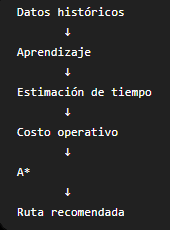

### 4.7 Función de costo con pesos

Se define una función de costo que combina tiempo, combustible y riesgo mediante pesos configurables.

In [36]:
# Función de costo con pesos configurables
def calcular_costo_pesos(ruta, pesos):
    costo_total = 0
    for i in range(len(ruta) - 1):
        origen = ruta[i]
        destino = ruta[i + 1]
        datos = tramos.get(
            (origen, destino),
            tramos.get((destino, origen))
        )
        tiempo = datos["tiempo_estimado"]
        combustible = datos["combustible"]
        riesgo = datos["riesgo"]
        costo = (
            pesos["tiempo"] * tiempo
            + pesos["combustible"] * combustible
            + pesos["riesgo"] * riesgo
        )
        costo_total += costo
    return round(costo_total, 2)

In [37]:
# Pesos iniciales

pesos_iniciales = {
    "tiempo": 0.5,
    "combustible": 0.3,
    "riesgo": 0.2
}

print("Pesos iniciales:")
print(pesos_iniciales)

print(
    "\nCosto de la ruta actual:",
    calcular_costo_pesos(
        ruta_final_a,
        pesos_iniciales
    )
)

Pesos iniciales:
{'tiempo': 0.5, 'combustible': 0.3, 'riesgo': 0.2}

Costo de la ruta actual: 17.81


### 4.8 Optimización de los pesos

Se utiliza Hill Climbing para buscar una configuración de pesos que reduzca
el costo entre las rutas factibles del espacio de estados.

En cada iteración se generan pequeñas variaciones de los pesos asociados al
tiempo, combustible y riesgo. Las nuevas configuraciones se evalúan sobre
las rutas disponibles y se conserva aquella que presenta una mejora en el
costo.

El proceso continúa hasta que ninguna configuración vecina permite obtener
una mejora adicional.

In [38]:
# Hill Climbing para optimizar los pesos de la función de costo
def generar_vecinos(pesos):
    vecinos = []
    paso = 0.1
    peso_minimo = 0.1
    factores = [
        "tiempo",
        "combustible",
        "riesgo"
    ]
    for factor in factores:
        for cambio in [-paso, paso]:
            nuevos_pesos = pesos.copy()
            nuevos_pesos[factor] += cambio
            # Evitar que algún factor desaparezca completamente
            if nuevos_pesos[factor] < peso_minimo:
                continue
            # Normalizar para que la suma sea 1
            suma = sum(nuevos_pesos.values())
            for clave in nuevos_pesos:
                nuevos_pesos[clave] /= suma
            # Verificar nuevamente el mínimo
            if all(
                peso >= peso_minimo
                for peso in nuevos_pesos.values()
            ):
                vecinos.append(nuevos_pesos)
    return vecinos

def evaluar_pesos(pesos):
    """
    Evalúa los pesos sobre todas las rutas posibles
    y devuelve la ruta de menor costo.
    """
    mejor_ruta = None
    mejor_costo = float("inf")
    for ruta in rutas:
        costo = calcular_costo_pesos(
            ruta,
            pesos
        )
        if costo < mejor_costo:
            mejor_costo = costo
            mejor_ruta = ruta
    return mejor_ruta, mejor_costo
def hill_climbing(pesos_iniciales):
    pesos_actuales = pesos_iniciales.copy()
    ruta_actual, costo_actual = evaluar_pesos(
        pesos_actuales
    )
    while True:
        vecinos = generar_vecinos(
            pesos_actuales
        )
        mejor_peso = pesos_actuales
        mejor_ruta = ruta_actual
        mejor_costo = costo_actual
        for vecino in vecinos:
            ruta_vecino, costo_vecino = evaluar_pesos(
                vecino
            )
            if costo_vecino < mejor_costo:
                mejor_peso = vecino
                mejor_ruta = ruta_vecino
                mejor_costo = costo_vecino

        # Si ningún vecino mejora la solución,
        # se alcanzó el máximo local
        if mejor_costo >= costo_actual:
            break
        pesos_actuales = mejor_peso
        ruta_actual = mejor_ruta
        costo_actual = mejor_costo

    return (
        pesos_actuales,
        ruta_actual,
        costo_actual
    )

In [39]:
# Ejecutar Hill Climbing

(
    pesos_optimizados,
    ruta_hill_climbing,
    costo_optimizado
) = hill_climbing(
    pesos_iniciales
)

print("RESULTADO DE HILL CLIMBING\n")

print("Pesos iniciales:")
for factor, peso in pesos_iniciales.items():
    print(f"{factor}: {peso:.3f}")

print("\nPesos optimizados:")
for factor, peso in pesos_optimizados.items():
    print(f"{factor}: {peso:.3f}")

print("\nRuta seleccionada por Hill Climbing:")
print(" → ".join(ruta_hill_climbing))

print("\nCosto inicial:")

_, costo_inicial_hc = evaluar_pesos(
    pesos_iniciales
)

print(round(costo_inicial_hc, 2))

print("\nCosto optimizado:")
print(round(costo_optimizado, 2))

RESULTADO DE HILL CLIMBING

Pesos iniciales:
tiempo: 0.500
combustible: 0.300
riesgo: 0.200

Pesos optimizados:
tiempo: 0.106
combustible: 0.160
riesgo: 0.735

Ruta seleccionada por Hill Climbing:
Carga → Cruce_A → Cruce_C → Descarga

Costo inicial:
17.81

Costo optimizado:
5.1


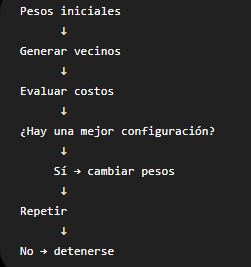

### 4.9 A* con pesos optimizados

Se aplica A* utilizando los pesos obtenidos mediante Hill Climbing.

In [40]:
# A* utilizando los pesos optimizados
def obtener_costo_optimizado(origen, destino, pesos):
    datos = tramos.get(
        (origen, destino),
        tramos.get((destino, origen))
    )
    tiempo = datos["tiempo_estimado"]
    combustible = datos["combustible"]
    riesgo = datos["riesgo"]
    return (
        pesos["tiempo"] * tiempo
        + pesos["combustible"] * combustible
        + pesos["riesgo"] * riesgo
    )
def a_estrella_optimizado(inicio, objetivo, pesos):
    abiertos = [
        {
            "estado": inicio,
            "ruta": [inicio],
            "g": 0,
            "f": distancia_heuristica(inicio, objetivo)
        }
    ]
    visitados = []
    while abiertos:
        mejor = min(
            abiertos,
            key=lambda x: x["f"]
        )
        abiertos.remove(mejor)
        estado = mejor["estado"]
        ruta = mejor["ruta"]
        costo_actual = mejor["g"]
        if estado == objetivo:
            return ruta, costo_actual
        if estado in visitados:
            continue
        visitados.append(estado)
        for vecino in conexiones[estado]:
            if vecino in visitados:
                continue
            costo_tramo = obtener_costo_optimizado(
                estado,
                vecino,
                pesos
            )
            nuevo_g = costo_actual + costo_tramo
            h = distancia_heuristica(
                vecino,
                objetivo
            )
            nuevo_f = nuevo_g + h
            abiertos.append(
                {
                    "estado": vecino,
                    "ruta": ruta + [vecino],
                    "g": nuevo_g,
                    "f": nuevo_f
                }
            )

    return None, None

### 4.10 Resultado final

- **Ruta:** Carga → Cruce_A → Cruce_C → Descarga
- **Costo optimizado:** 5.10
- **Pesos:** Tiempo = 0.106 | Combustible = 0.160 | Riesgo = 0.735

La ruta final es obtenida mediante A* utilizando los pesos optimizados
por Hill Climbing. Estos pesos permiten ajustar la función de costo
considerando conjuntamente el tiempo, el combustible y el riesgo de
cada tramo.

In [41]:
# Obtener la ruta final del sistema
ruta_optima, costo_optimo = a_estrella_optimizado(
    "Carga",
    "Descarga",
    pesos_optimizados
)
print("RESULTADO FINAL DEL SISTEMA\n")
print("Ruta óptima:")
print(" → ".join(ruta_optima))
print("\nCosto optimizado:",
      round(costo_optimo, 2))
print("\nPesos utilizados:")
for factor, peso in pesos_optimizados.items():
    print(f"{factor}: {peso:.3f}")

RESULTADO FINAL DEL SISTEMA

Ruta óptima:
Carga → Cruce_A → Cruce_C → Descarga

Costo optimizado: 5.1

Pesos utilizados:
tiempo: 0.106
combustible: 0.160
riesgo: 0.735


In [42]:
# Comparación final de las estrategias de búsqueda

print("COMPARACIÓN FINAL DE ESTRATEGIAS\n")

print("BFS")
print("Ruta:", " → ".join(ruta_bfs))
print("Número de estados:", len(ruta_bfs))

print("\nDFS")
print("Ruta:", " → ".join(ruta_dfs))
print("Número de estados:", len(ruta_dfs))

print("\nFUERZA BRUTA")
print("Ruta:", " → ".join(mejor_ruta))
print("Costo:", menor_costo)

print("\nA* INICIAL")
print("Ruta:", " → ".join(ruta_a_estrella))
print("Costo:", round(costo_a_estrella, 2))

print("\nA* CON APRENDIZAJE Y OPTIMIZACIÓN")
print("Ruta:", " → ".join(ruta_optima))
print("Costo:", round(costo_optimo, 2))

COMPARACIÓN FINAL DE ESTRATEGIAS

BFS
Ruta: Carga → Cruce_A → Cruce_C → Descarga
Número de estados: 4

DFS
Ruta: Carga → Cruce_B → Cruce_D → Descarga
Número de estados: 4

FUERZA BRUTA
Ruta: Carga → Cruce_B → Cruce_D → Descarga
Costo: 18.96

A* INICIAL
Ruta: Carga → Cruce_B → Cruce_D → Descarga
Costo: 18.96

A* CON APRENDIZAJE Y OPTIMIZACIÓN
Ruta: Carga → Cruce_A → Cruce_C → Descarga
Costo: 5.1


### 4.11 Comparación final de estrategias

Se comparan las rutas obtenidas mediante BFS, DFS, Fuerza Bruta y A*,
incluyendo la solución final obtenida después de incorporar aprendizaje
y optimización.

| Estrategia | Considera costo | Utiliza información adicional | Función en el sistema |
|---|---|---|---|
| **BFS** | No | No | Comparación |
| **DFS** | No | No | Comparación |
| **Fuerza Bruta** | Sí | No | Referencia |
| **A\*** | Sí | No | Búsqueda inicial |
| **A\* + aprendizaje + optimización** | Sí | Sí | Solución final |

### Interpretación

BFS y DFS permiten explorar el espacio de estados mediante estrategias
de búsqueda no informadas. En el escenario evaluado, ambas encuentran
una ruta factible entre `Carga` y `Descarga`.

La Fuerza Bruta evalúa las rutas factibles y permite establecer una
referencia para el problema.

A* incorpora información de los costos y una heurística basada en la
distancia para orientar la búsqueda hacia el estado objetivo.

Posteriormente, se incorpora información histórica para actualizar el
costo operativo de los tramos. Finalmente, Hill Climbing modifica los
pesos de tiempo, combustible y riesgo, y estos pesos son utilizados por
A* para realizar una nueva búsqueda.

De esta manera, el sistema combina búsqueda, aprendizaje y optimización
en un mismo proceso.

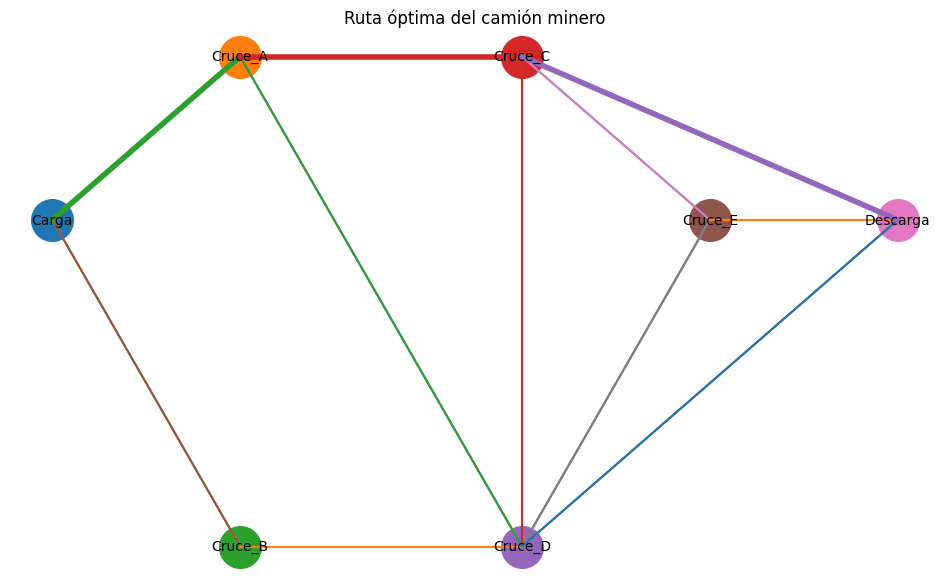

In [43]:
# Visualizar la ruta final encontrada por A*
plt.figure(figsize=(12, 7))
# Dibujar todos los caminos
for origen, vecinos in conexiones.items():
    for destino in vecinos:
        x1, y1 = coordenadas[origen]
        x2, y2 = coordenadas[destino]
        plt.plot(
            [x1, x2],
            [y1, y2],
            linewidth=1.5
        )
# Dibujar la ruta óptima
for i in range(len(ruta_optima) - 1):
    origen = ruta_optima[i]
    destino = ruta_optima[i + 1]
    x1, y1 = coordenadas[origen]
    x2, y2 = coordenadas[destino]
    plt.plot(
        [x1, x2],
        [y1, y2],
        linewidth=4
    )
# Dibujar los estados
for nombre, (x, y) in coordenadas.items():
    plt.scatter(x, y, s=900)
    plt.text(
        x,
        y,
        nombre,
        ha="center",
        va="center",
        fontsize=10
    )
plt.title("Ruta óptima del camión minero")
plt.axis("off")
plt.show()

### 4.12 Ruta óptima obtenida

La ruta final obtenida mediante A* después del proceso de aprendizaje y
optimización es:

**Carga → Cruce_A → Cruce_C → Descarga**

La ruta está compuesta por tres tramos y presenta una distancia total de
9.52 km, un tiempo estimado de 29.4 minutos y un riesgo acumulado de
0.53.

La visualización permite observar el recorrido seleccionado desde el
estado inicial `Carga` hasta el estado objetivo `Descarga`.

In [49]:
# Métricas de la ruta final

distancia_total = 0
tiempo_total = 0
combustible_total = 0
riesgo_total = 0

for i in range(len(ruta_optima) - 1):

    origen = ruta_optima[i]
    destino = ruta_optima[i + 1]

    datos = tramos.get(
        (origen, destino),
        tramos.get((destino, origen))
    )

    distancia_total += datos["distancia"]
    tiempo_total += datos["tiempo_estimado"]
    combustible_total += datos["combustible"]
    riesgo_total += datos["riesgo"]

print("MÉTRICAS DE LA RUTA FINAL\n")

print("Ruta:")
print(" → ".join(ruta_optima))

print("\nNúmero de tramos:",
      len(ruta_optima) - 1)

print("Distancia total:",
      round(distancia_total, 2), "km")

print("Tiempo estimado total:",
      round(tiempo_total, 2), "min")

print("Índice de combustible:",
      round(combustible_total, 2))

print("Riesgo acumulado:",
      round(riesgo_total, 2))

print("Costo operativo:",
      round(costo_optimo, 2))

MÉTRICAS DE LA RUTA FINAL

Ruta:
Carga → Cruce_A → Cruce_C → Descarga

Número de tramos: 3
Distancia total: 9.52 km
Tiempo estimado total: 29.4 min
Índice de combustible: 10.01
Riesgo acumulado: 0.53
Costo operativo: 5.1


### 4.13 Métricas de la ruta final

Se calculan las métricas principales de la ruta final: distancia, tiempo, combustible y riesgo.

In [47]:
# Comparar la solución inicial con la solución final

# Solución inicial: A* original
ruta_inicial = ruta_a_estrella
costo_inicial = costo_a_estrella

# Solución final: A* con pesos optimizados
ruta_final = ruta_optima
costo_final = costo_optimo

print("COMPARACIÓN DE RESULTADOS\n")

print("Solución inicial")
print("Ruta:", " → ".join(ruta_inicial))
print("Costo:", round(costo_inicial, 2))

print("\nSolución final")
print("Ruta:", " → ".join(ruta_final))
print("Costo:", round(costo_final, 2))

print("\nPesos iniciales:")
for factor, peso in pesos_iniciales.items():
    print(f"{factor}: {peso:.3f}")

print("\nPesos optimizados:")
for factor, peso in pesos_optimizados.items():
    print(f"{factor}: {peso:.3f}")

COMPARACIÓN DE RESULTADOS

Solución inicial
Ruta: Carga → Cruce_B → Cruce_D → Descarga
Costo: 18.96

Solución final
Ruta: Carga → Cruce_A → Cruce_C → Descarga
Costo: 5.1

Pesos iniciales:
tiempo: 0.500
combustible: 0.300
riesgo: 0.200

Pesos optimizados:
tiempo: 0.106
combustible: 0.160
riesgo: 0.735


## Evaluación de la solución

La solución inicial utiliza los pesos definidos previamente para los
criterios de tiempo, combustible y riesgo.

Posteriormente, Hill Climbing genera pequeñas variaciones de estos pesos
y evalúa las diferentes configuraciones considerando las rutas factibles.
Cuando encuentra una configuración que reduce el costo, esta se utiliza
como nuevo punto de búsqueda.

El proceso obtiene los siguientes pesos optimizados:

- **Tiempo:** 0.106
- **Combustible:** 0.160
- **Riesgo:** 0.735

Estos pesos son utilizados posteriormente por A* para realizar una nueva
búsqueda sobre la red de transporte.

La solución final obtenida corresponde a:

**Carga → Cruce_A → Cruce_C → Descarga**

con un costo de **5.10** bajo la función de costo optimizada.

De esta manera, el pipeline desarrollado sigue la secuencia:

**Búsqueda → Aprendizaje → Optimización → Nueva búsqueda**

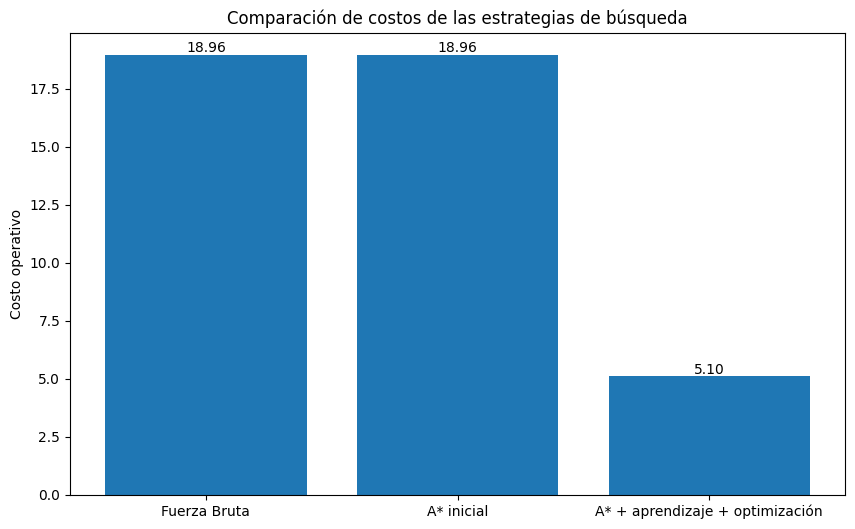

In [48]:
# Comparación visual de los costos

nombres = [
    "Fuerza Bruta",
    "A* inicial",
    "A* + aprendizaje + optimización"
]
costos = [
    menor_costo,
    costo_inicial,
    costo_final
]
plt.figure(figsize=(10, 6))
plt.bar(
    nombres,
    costos
)
plt.ylabel("Costo operativo")
plt.title("Comparación de costos de las estrategias de búsqueda")
for i, costo in enumerate(costos):
    plt.text(
        i,
        costo,
        f"{costo:.2f}",
        ha="center",
        va="bottom"
    )
plt.show()

## Comparación visual

La gráfica permite observar los costos calculados para la Fuerza Bruta,
A* inicial y A* después del proceso de aprendizaje y optimización.

La Fuerza Bruta se utiliza como referencia del espacio de rutas
evaluado, mientras que A* incorpora información heurística para orientar
la búsqueda.

En la solución final, A* utiliza los pesos obtenidos mediante Hill
Climbing para calcular el costo de las rutas considerando conjuntamente
los criterios de tiempo, combustible y riesgo.

El resultado de la solución final presenta un costo de **5.10** bajo la
función de costo correspondiente a los pesos optimizados.

# Conclusiones

El problema de determinar la ruta óptima de camiones mineros fue
representado mediante un espacio de estados compuesto por nodos y
conexiones que representan una red de transporte entre la zona de carga
y las zonas de descarga.

Se implementaron diferentes estrategias de búsqueda:

- **BFS:** permitió explorar el espacio de estados por niveles y obtener
  una ruta factible.
- **DFS:** permitió explorar las alternativas en profundidad y obtener
  una ruta factible.
- **Fuerza Bruta:** permitió evaluar las rutas factibles y establecer una
  referencia para el problema.
- **A\*:** permitió realizar una búsqueda informada mediante el costo
  acumulado y una estimación de la distancia restante.

Posteriormente, se incorporó información histórica para estimar el
tiempo de recorrido y actualizar el costo operativo de los tramos.

A partir de esta información se aplicó Hill Climbing para ajustar los
pesos asociados al tiempo, combustible y riesgo. El proceso obtuvo los
pesos:

- **Tiempo:** 0.106
- **Combustible:** 0.160
- **Riesgo:** 0.735

Estos pesos fueron utilizados posteriormente por A* para realizar la
búsqueda final.

La ruta final obtenida fue:

**Carga → Cruce_A → Cruce_C → Descarga**

Esta ruta presenta tres tramos, una distancia total de **9.52 km**, un
tiempo estimado de **29.4 minutos** y un riesgo acumulado de **0.53**.
El costo calculado bajo la función de costo optimizada fue de **5.10**.

En conjunto, el desarrollo muestra cómo una estrategia de búsqueda puede
combinar información histórica y optimización de parámetros para
replantear la función de costo y realizar una nueva búsqueda sobre el
espacio de estados.

El pipeline desarrollado sigue la secuencia:

**Representación del problema → Espacio de estados → Búsqueda →
Aprendizaje → Optimización → Nueva búsqueda → Ruta final**